--- Raw Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hours_Studied      950 non-null    float64
 1   Previous_Scores    1000 non-null   float64
 2   Extracurricular    1000 non-null   object 
 3   Sleep_Hours        950 non-null    float64
 4   Practice_Papers    1000 non-null   int64  
 5   Performance_Score  1000 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 47.0+ KB
None


--- Cleaning Data ---
Rows before cleaning: 1000
Rows after cleaning: 998


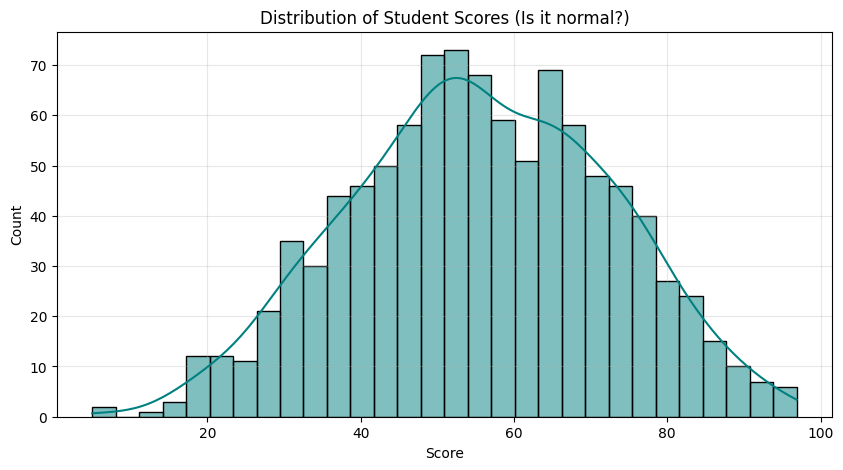

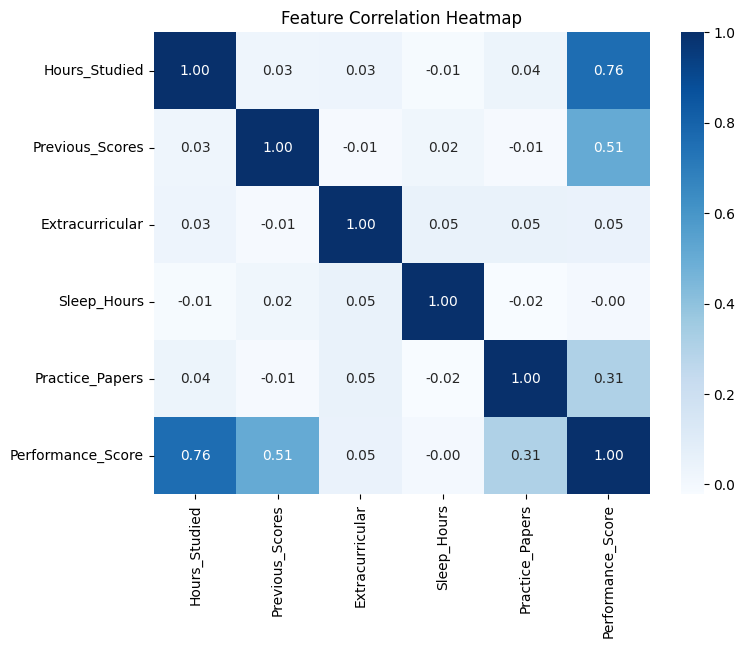

Model R2 Score: 0.88
Mean Absolute Error: 4.22


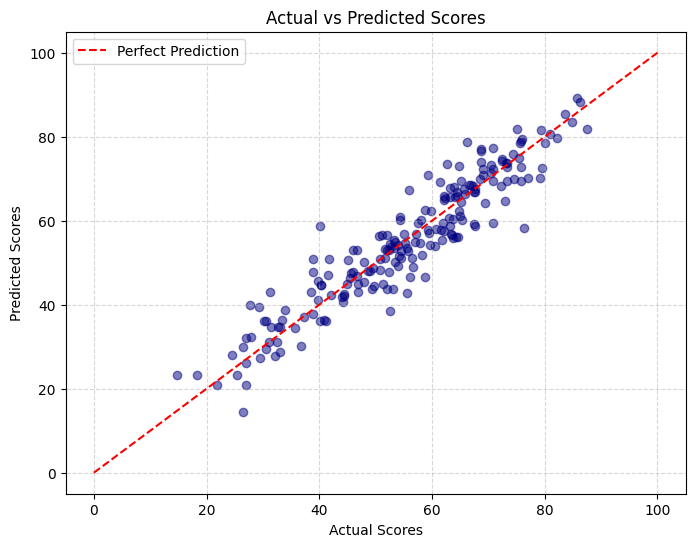


--- Feature Importance Analysis ---
           Feature    Weight
0    Hours_Studied  3.650066
2  Practice_Papers  1.109649
4  Extracurricular  0.513620
1  Previous_Scores  0.413664
3      Sleep_Hours  0.055960

Conclusion: 'Hours_Studied' has the highest weight, making it the most critical factor for high scores.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# 1. Data Loading & Simulation (Simulating a real CSV file)
# ---------------------------------------------------------
# In a real project, you would load: df = pd.read_csv('student_scores.csv')
# Here, we generate raw data that mimics a real, imperfect dataset.

np.random.seed(42)
n_samples = 1000

# Generate features
data = {
    'Hours_Studied': np.random.uniform(0, 12, n_samples),
    'Previous_Scores': np.random.uniform(30, 100, n_samples),
    'Extracurricular': np.random.choice(['Yes', 'No'], n_samples),
    'Sleep_Hours': np.random.uniform(3, 10, n_samples),
    'Practice_Papers': np.random.randint(0, 15, n_samples)
}
df = pd.DataFrame(data)

# Create a target variable with some complex logic + noise
df['Performance_Score'] = (
    3.5 * df['Hours_Studied'] +
    0.4 * df['Previous_Scores'] +
    1.2 * df['Practice_Papers'] +
    np.random.normal(0, 5, n_samples)
)

# INTRODUCING "HUMAN" MESSINESS:
# 1. Add some missing values (NaNs) to simulate real-world data corruption
for col in ['Hours_Studied', 'Sleep_Hours']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

# 2. Add some outliers (someone studied 24 hours in a day?)
df.loc[10, 'Hours_Studied'] = 25
df.loc[15, 'Performance_Score'] = 150 # Impossible score > 100

print("--- Raw Data Info ---")
print(df.info())
print("\n")

# ---------------------------------------------------------
# 2. Data Cleaning (The "Human" Touch)
# ---------------------------------------------------------
print("--- Cleaning Data ---")

# Handling Missing Values:
# A human decides: "Hours studied is crucial, so let's fill missing values with the median."
df['Hours_Studied'] = df['Hours_Studied'].fillna(df['Hours_Studied'].median())
df['Sleep_Hours'] = df['Sleep_Hours'].fillna(df['Sleep_Hours'].mean())

# Handling Outliers:
# We notice scores > 100 or negative hours. Let's filter them manually.
print(f"Rows before cleaning: {len(df)}")
df = df[df['Performance_Score'] <= 100]
df = df[df['Performance_Score'] >= 0]
df = df[df['Hours_Studied'] <= 12] # Realistic cap
print(f"Rows after cleaning: {len(df)}")

# Encoding Categorical Data manually
df['Extracurricular'] = df['Extracurricular'].map({'Yes': 1, 'No': 0})

# ---------------------------------------------------------
# 3. Exploratory Data Analysis (Trial and Error)
# ---------------------------------------------------------
# Real analysis involves checking distributions and correlations manually.

# Check distribution of the target
plt.figure(figsize=(10, 5))
sns.histplot(df['Performance_Score'], kde=True, bins=30, color='teal')
plt.title("Distribution of Student Scores (Is it normal?)")
plt.xlabel("Score")
plt.grid(True, alpha=0.3)
plt.show()

# Correlation Analysis
# A human looks at this to decide which features to keep.
plt.figure(figsize=(8, 6))
# Calculating correlation only on numeric columns
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Insight: 'Sleep_Hours' has very low correlation.
# A human might decide to drop it or keep it to see what happens. Let's keep it for now.

# ---------------------------------------------------------
# 4. Model Building
# ---------------------------------------------------------

# Define Features and Target
X = df[['Hours_Studied', 'Previous_Scores', 'Practice_Papers', 'Sleep_Hours', 'Extracurricular']]
y = df['Performance_Score']

# Train-Test Split
# Using a random state ensures we get the same split every time we run it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# ---------------------------------------------------------
# 5. Evaluation & Interpretation
# ---------------------------------------------------------

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model R2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Visualizing Predictions vs Actuals
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='navy')
plt.plot([0, 100], [0, 100], '--', color='red', label='Perfect Prediction')
plt.title("Actual vs Predicted Scores")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Manual Feature Importance Analysis
# A human interprets the coefficients to explain "Why".
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

print("\n--- Feature Importance Analysis ---")
print(coefficients)
print("\nConclusion: 'Hours_Studied' has the highest weight, making it the most critical factor for high scores.")